# ME-433 Rocket Science
## HW 4
### Fanno flow & Supersonic Lift/Drag

#### Question 1 
Assume that coming into a pipe there exists a Mach 0.5 flow at 101325 Pa of pressure and 300 K temperature, gamma 1.4. If it first passes through a frictionless pipe with heat addition, and then passes through an adiabatic pipe with friction in such a fashion that it always results in an exit flow at M = 1. Determine all combinations of heat addition q, and pipe length L, for a friction factor of 0.004 and pipe diameter of 0.1 m which can
achieve this result. Plot your result as a graph of L as a function of q.

Assuming 
1. Steady state $\frac{\partial}{\partial t} = 0 $
2. inviscid flow with no internal viscocity 
3. Calorically perfect gas (CPG)
4. Cp approximation at 300K at 1.005 KJ/Kg * K



### FOR RAYLEIGH FLOW : 
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW4/Rayleigh%20star%20relationships.png?raw=true" width="50%">

<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW4/Rayleigh%20starred%20quantities%20definition.png?raw=true" width="50%">


### FOR FANNO FLOW : 
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW4/Fanno%20Flow%20relationship.png?raw=true" width="50%">




### strategy 

1. Wtih Rayleigh flow, I can calculate the energy input q as the function of outgoing mach M2 
2. With Fanno flow, I can calculate the required length to push to mach  L* as a function of M2 
3. Thus, this question is implicit parametric sweep of M2 from [0.5,1], data collection of the  q2 an L*, and plotting

In [7]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import brentq


# CONSTANTS 
M_i = 0.5 #Mach number
P_i = 101325 #Pa 
T_i = 300 #K 
gamma = 1.4 #heat capacity ratio 
M2 = np.linspace(0.5, 1, 1000)
D = 0.1 
f = 0.004

#Lists to solve problem 
Lstar_q1 = []
Lstar_q2 = []


#Stagnation Temperature relationship, only works for isentropic process
def stagTemp(m, gamma, T): 
    M = m ** 2
    T_stag = (1 + ((gamma - 1)/2 ) * M) * T
    return T_stag
print(stagTemp(M_i, gamma, T_i))

315.0


In [101]:
#Lstar as dictionary of [m2, q, Lstar] value
# where m2 is a sweep of possible in-between mach values 
# q2 is required heat input to go from init to m2 mach 
# Lstar is required length to go from m2 to mach 1 


#RayleighFlow_q1 takes in the mach number, gamma, Inlet Temperature and return q 

def T_Ostar_ratio(m, gamma): 
    M = m ** 2
    return ((gamma + 1)*M)/((1+gamma*M)**2) * (2 + (gamma - 1)* M)

def RayleighFlow_q1(m_i, m_2, gamma, T_i):
    
    T_O1star_ratio = T_Ostar_ratio(m_i, gamma)
    T_O2star_ratio = T_Ostar_ratio(m_2, gamma)
   
    T_O1 = stagTemp(m_i, gamma, T_i)
    T_Ostar = T_O1/T_O1star_ratio
    T_O2 = T_O2star_ratio * T_Ostar

    q = 1.005 * (T_O2 - T_O1)

    return q

#FannoFlow q1 takes in the mach number, gamma, pipe Diameter, 
# and friction to output Lstar
def FannoFlow_q1(m, gamma, D, f): 
    M = m ** 2 
    fanno = ((1-M)/(gamma * M)) + (((gamma + 1)/(2 * gamma))) * np.log(((gamma + 1)*M)/(2 + (gamma -1)*M))
    Lstar = (fanno * D)/(4 * f)
    return(fanno, Lstar)

for m in M2: 
    _, Lstar = FannoFlow_q1(m, gamma, D, f)
    q = RayleighFlow_q1(M_i, m, gamma,T_i)

    Lstar_q1.append([m, q, Lstar])

print(Lstar_q1[:5])

[[np.float64(0.5), np.float64(0.0), np.float64(6.681626954489099)], [np.float64(0.5005005005005005), np.float64(0.3351301266862836), np.float64(6.6561392263064025)], [np.float64(0.501001001001001), np.float64(0.6698495317608697), np.float64(6.630747250288577)], [np.float64(0.5015015015015015), np.float64(1.0041577613495465), np.float64(6.605450621320549)], [np.float64(0.502002002002002), np.float64(1.338054365035181), np.float64(6.5802489363491175)]]


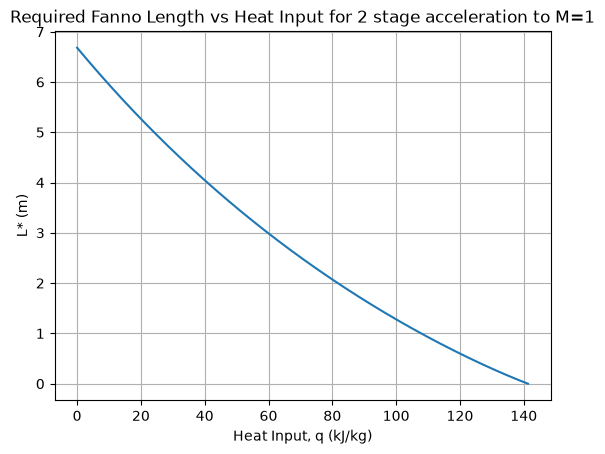

In [105]:
q_values = [row[1] for row in Lstar_q1]
Lstar_values = [row[2] for row in Lstar_q1]

plt.plot(q_values, Lstar_values)

plt.xlabel("Heat Input, q (kJ/kg)")
plt.ylabel("L* (m)")
plt.title("Required Fanno Length vs Heat Input for 2 stage acceleration to M=1")
plt.grid(True)
plt.show()


#### Question 2
Reverse the order of the processes in problem 1, comment on the differences in the two plots

In [107]:
#similar approach to Q1 

#Fanno_q2 need to take the M2, M_i, gamma,  friction, diameter 
#And return the length required to accelerate M_i to M_2 
#And return the temperature of M2 
def FannoFlow_q2(m_i, m_2, gamma, D, f, T): 
    M_i = m_i **2 
    M_2 = m_2 **2
    Fanno_M1 = -1/(gamma * M_i) - ((gamma+1)/(2*gamma)) * np.log(M_i)/(1 + ((gamma-1)/2)*M_i)
    Fanno_M2 = -1/(gamma * M_2) - ((gamma+1)/(2*gamma)) * np.log(M_2)/(1 + ((gamma-1)/2)*M_2)
    L = ((Fanno_M2-Fanno_M1) * D)/(4 * f)
    T_m2 = T * ((2 + (gamma-1)*M_i)/(2 + (gamma -1)*M_2))
    return T_m2, L

#Rayleigh_q2 need to take in M2 and find the required heat input q to reach the choke state 
# I can just reuse Rayleigh_q1 function and set the m_2, the end state Mach number, to 1


In [111]:
for m in M2: 
    T_m2, Lstar = FannoFlow_q2(M_i, m, gamma, D, f, T_i)
    q = RayleighFlow_q1(m, 1, gamma,T_m2)

    Lstar_q2.append([m, q, Lstar])

print(Lstar_q1[:5])

[[np.float64(0.5), np.float64(0.0), np.float64(6.681626954489099)], [np.float64(0.5005005005005005), np.float64(0.3351301266862836), np.float64(6.6561392263064025)], [np.float64(0.501001001001001), np.float64(0.6698495317608697), np.float64(6.630747250288577)], [np.float64(0.5015015015015015), np.float64(1.0041577613495465), np.float64(6.605450621320549)], [np.float64(0.502002002002002), np.float64(1.338054365035181), np.float64(6.5802489363491175)]]


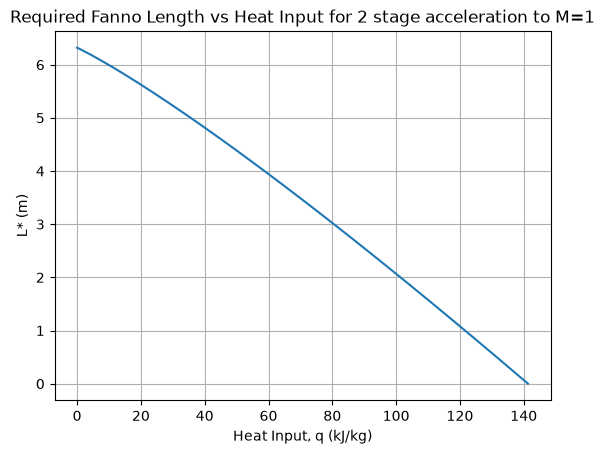

In [112]:
q_values = [row[1] for row in Lstar_q2]
Lstar_values = [row[2] for row in Lstar_q2]

plt.plot(q_values, Lstar_values)

plt.xlabel("Heat Input, q (kJ/kg)")
plt.ylabel("L* (m)")
plt.title("Required Fanno Length vs Heat Input for 2 stage acceleration to M=1")
plt.grid(True)
plt.show()

 Both graphs are similar that if you incrase the length of the Fanno Flow, you need less heat input and vice versa. The results of q1 and q2 verifies themselves as they have the same end-states. 
 However, they concave in different ways. This shows that 2-stage acceleration of Fanno Flow and Rayleigh flow is not a commutative process


#### Question 3 
Attached to your HW are four airfoil designs all given as the top surface of a symmetric airfoil in .txt format where the top row is x position and the bottom is y position. Plot on the same graph the lift coefficient as a function of the drag coefficient for the range of angle of attack from - 5 to 5 degrees. Assume a Mach number of 3 and gamma 1.4. You can take $L = \frac{1}{2}\rho v^2 C_L A $  and $D = \frac{1}{2}\rho v^2 C_D A $



as the appropriate expressions for lift and drag. Note that these are oriented normal to the wind for lift and parallel to the wind for drag. The area in these expressions can be taken to be the planform area of the wing, so its tip to tail length multiplied by a 1 m width into the page. Note that the density and velocity in the expressions above are the free stream values. The choice of a pressure and temperature is not necessary but for ease of calculation you can assume 1 atm and 300 K.

In [5]:
#Takes in m and gamma to return nu_m, deflection angle in radian
def PrandtlMeyer (m, gamma): 
    M = m **2 
    nu_m = np.sqrt(((gamma+1)/(gamma-1))) * np.atan(np.sqrt(((gamma-1)/(gamma+1))*(M-1))) - np.atan(np.sqrt(M-1))
    return nu_m

#Brentq is part of the Scipy otpimization package, that utilizes Brents method to find the solution to m from nu_m
def InversePrandtlMeyer (nu_m, gamma):
    m = brentq(lambda m: PrandtlMeyer(m, gamma) - nu_m, 1, 1e6)
    return m

#ExpansionWave function takes in m_i, gamma, theta (deflection in degrees) and P_i, and outputs pressure and m_2
def ExpansionWave(m_i, gamma, theta, P_i): 
    nu_m_i = PrandtlMeyer(m_i, gamma)    
    nu_m_2 = nu_m_i + np.deg2rad(abs(theta))
    m_2 = InversePrandtlMeyer(nu_m_2, gamma)

    M_i = m_i ** 2 
    M_2 = m_2 ** 2

#P_ratio = P_i/P_2
    P_ratio = ((1+ ((gamma-1)/2) * M_2)/(1 + ((gamma-1)/2) * M_i)) ** ((gamma)/(gamma-1))
    P_2 = P_i/P_ratio 

    return P_2, m_2

In [6]:
ExpansionWave(1.5, 1.4, 11, 1700)

NameError: name 'np' is not defined

The following two functions are from HW3

In [4]:
def BetaTheta (m, gamma, theta):
    Theta = np.deg2rad(theta)
    M = m ** 2
    L = np.sqrt(((M-1) ** 2 - 3 * (1 + ((gamma - 1)/2)*M) * (1 + ((gamma + 1)/2)*M) * np.tan(Theta) ** 2))
    X = ((M - 1) ** 3 - 9*(1 + ((gamma - 1)/2)*M)* (1 + ((gamma - 1)/2)*M + ((gamma+1)/4)* M**2) * (np.tan(Theta) **2))/ (L** 3)

    tanBeta_numerator_weak = M - 1 + 2 * L * np.cos((4*np.pi + np.arccos(X)) / 3)
    tanBeta_numerator_strong = M - 1 + 2 * L * np.cos((np.arccos(X)) / 3)
    tanBeta_denominator = 3 * (1 + ((gamma - 1)/ 2) * M)* np.tan(Theta)
    tanBeta_strong = tanBeta_numerator_strong/tanBeta_denominator
    tanBeta_weak = tanBeta_numerator_weak/tanBeta_denominator
    return np.rad2deg(np.arctan(tanBeta_strong)), np.rad2deg(np.arctan(tanBeta_weak))

def ObliqueShock(M_1,gamma, theta):
    #Function that takes incoming Mach Number(M_1), ratio of specific heats(gamma), and turning angle(theta)
    #to return pressure ratio(P), temperature ratio(T), and outgoing Mach number(M_2)
    # In the process, calculate normal element of M_1 denoted M_1_n
    # In the process, calculate density ratio Rho
    beta_strong, beta_weak = BetaTheta(M_1, gamma, theta)


    # M_1_n and Rho calculation
    M_1_n = M_1 * np.sin(np.deg2rad(beta_weak))
    Rho = ((gamma + 1) * (M_1_n * M_1_n)) / ((gamma - 1) * (M_1_n * M_1_n)+2)
    P = 1 + (((2 * gamma) / (gamma + 1)) * (M_1_n * M_1_n - 1))
    T = (1 / Rho) * P
    M_2_n_squared = ((M_1_n * M_1_n) + (2 / (gamma - 1))) / ((((2 * gamma) / (gamma - 1)) * (M_1_n * M_1_n)) - 1)
    M_2_n = np.sqrt(M_2_n_squared)
    M_2 = M_2_n / np.sin(np.deg2rad(beta_weak - theta))


    # The stagnation pressure loss for the case of oblique shock should be calculated in the form of stagnation pressure loss in the normal element of M1
    M = M_1_n ** 2
    stagLoss_pt1 = (((gamma + 1) * M )/((gamma - 1) * M + 2)) ** (gamma/(gamma-1))
    stagLoss_pt2 = ((gamma+1)/(2 * gamma * M - (gamma - 1))) ** (1/(gamma-1))
    stagLoss = stagLoss_pt1 * stagLoss_pt2

    return P, T, M_2, stagLoss

In [3]:
airfoils = {}
airfoil_def = {}
Processed_airfoil = {}


for i in range(1, 5):
    with open(f"airfoil{i}.txt", "r") as file:
        lines = file.readlines()
    x = [float(value) for value in lines[0].strip().split(",")]
    y = [float(value) for value in lines[1].strip().split(",")]
    airfoils[i] = [x, y]

airfoil_angles = {}
#use upwrap to identify rise or fall of angles
def AirfoilRead(airfoils): 
    for i in range(1, 5): 
        x, y = airfoils[i]
        
        theta = []
        L = []

        for j in range(1, len(x)):
            deltax = x[j] - x[j-1]
            deltay = y[j] - y[j-1]
            angle = np.rad2deg(np.arctan2(deltay, deltax))
            theta.append(angle)
            Length = np.sqrt((deltax **2 + deltay **2))
            L.append(Length)
        theta = np.unwrap(theta, period=360)   
        airfoil_def[i] = [x, theta, L]
    return airfoil_def

In [2]:
#Angle of Alpha is applied directly to the first member of the airfoil only 
#The mach flow moves along the surfaces of the airfoil, which is structurly fixed. Therefore, the second member onwards do not get affected 

def AirfoilProcess(airfoil_definitions, alpha):
    for i in range(1, 5):
        x, theta, L = airfoil_definitions[i]
        deltaTheta = [theta[0] - alpha]          
        for j in range(1, len(theta)):
            deltaTheta.append(theta[j] - theta[j-1])   
        Processed_airfoil[i] = [x, deltaTheta, L]

In [ ]:
AirfoilRead()

The strategy now is 
1. Process the given airfoil files into Processed Airfoil, that has [x, $\Delta\theta$, and L]. X is used as the identifier for segments

2a. If deltatheta > 0, use the Obliqueshock to find the next mach number and current section pressure. <br>
2b. If deltatheta < 0, use the Expansionwave to find the next mach number and current section pressure.

3. Multiply the pressure by area to find the force, use trig to divide it into x and y component 
4. Concat the X and Y to total Lift and Drag, X is drag and Y is lift
5. Use the given Lift and Drag function to find the coefficients of lift and drag 



### Question 4
Which airfoil does best? Typically for efficient operations it is desirable to maximize L/D. What conclusions can you draw from this analysis about the “optimal” design by this metric? Why is that a practical problem

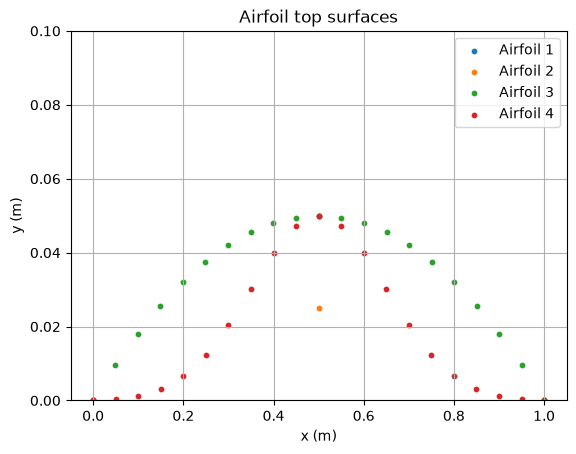

In [165]:
for i in range(1, 5):
        x, y = airfoils[i]
        plt.scatter(x, y, s=10, label=f"Airfoil {i}")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Airfoil top surfaces")
plt.ylim(0, 0.1)
plt.legend()
plt.grid(True)
plt.show()

